# UdaciMed | Notebook 1: Baseline Analysis

Welcome to UdaciMed! You are a Machine Learning Engineer tasked with optimizing our chest X-ray pneumonia detection model for production deployment.

- **The challenge**: Before our new model can be approved for production, we must verify that it meets our strict performance SLAs. Deploying an unoptimized model could lead to high operational costs and poor performance across our diverse hardware fleet—from shared T4 GPU cloud instances to portable clinic devices.

- **Your mission**: Optimize the model to pass _UdaciMed's Universal Performance Standard_, a strict production service level agreement (SLA) that must be met using the universally compatible ONNX format on our standardized target device.

### **Optimization goals**

Your goal is to ensure the production model meets these production targets on our standardized development machine:

- **< 0.4 GFLOPs per sample**: Floating Point Operations determine computational cost - reducing FLOPs is the most critical step toward broad-platform efficiency.
- **< 100MB peak memory footprint**: Total memory consumption (parameters + activations + workspace) during inference - essential for running the model on memory-constrained edge devices and for enabling cost-effective multi-model environments in the cloud.
- **< 3ms latency**: This ensures a real-time user experience. We will measure both *amortized latency* (average time per sample in a large batch) and *true latency* (time for a single-image inference), as both are important for different use cases.
- **> 2000 samples/second throughput**: This specific target is for our high-performance hardware, like the reference T4 GPU. Meeting this goal proves the model is cost-effective and scalable for high-volume, server-side screening workflows.
- **> 98% sensitivity***: This is a non-negotiable clinical safety requirement. We must ensure that a threshold percentage of all true pneumonia cases are correctly identified. All optimizations must be validated against this metric.

#### **A note on our standardized target device**

All performance targets in this project must be met on our official _"standardized target device."_ This is an NVIDIA T4 GPU, a common and versatile datacenter GPU that represents a typical cloud deployment environment.

By using a single, consistent hardware profile (NVIDIA T4 with 16GB VRAM, CUDA 12.4) for all our performance SLAs, we can:

- *Ensure Reproducible Results*: Anyone on the team can validate performance and get consistent measurements.

- *Create a Reliable Benchmark*: It provides a stable baseline to measure the impact of every optimization we make.

If a model can meet our strict, universal performance standards on this reference hardware, we are confident it will perform well across our entire fleet of production devices.

---

Through this notebook, you will build the foundation for our optimization strategy by:

1.  **Establishing baseline performance** with comprehensive profiling.
2.  **Analyzing the primary bottlenecks**, distinguishing between compute, parameter memory, and activation memory.
3.  **Identifying optimization opportunities** in both the model architecture and the deployment configuration.

**Let's set up an optimization vision for UdaciMed's next-generation diagnostic platform!**


> **_\*Understanding medical AI requirements_**:
> 
> In medical AI, sensitivity (recall) is often more critical than overall accuracy. Missing a pneumonia case (false negative) can be life-threatening, while a false positive "only" leads to additional human review. This is why we prioritize sensitivity as our safety constraint.

## Step 1: Set up the environment
The first step is to import all libraries and internal functionalities (from `utils`). 

Additionally, we set `pytorch` to use CUDA GPU if available (not only for faster execution, but also for benchmarking, as this will be our final deployment target!) and we include deterministic mode for reproducible benchmarking.

In [1]:
# Make sure that libraries are dynamically re-loaded if changed
%load_ext autoreload
%autoreload 2

In [2]:
# Import core libraries
import torch
import torch.nn as nn
import inspect
import numpy as np
import os
import pickle
from pprint import pprint
import random
from torchsummary import summary
import tqdm
import warnings
warnings.filterwarnings('ignore')

# Import project utilities
from utils.data_loader import (
    load_pneumoniamnist, 
    get_dataset_info, 
    explore_dataset_splits,
    visualize_sample_images,
    get_sample_batch
)
from utils.model import (
    create_baseline_model,
    get_model_info,
    count_parameters_by_type,
    train_baseline_model,
    plot_training_history
)
from utils.evaluation import (
    evaluate_with_multiple_thresholds
)
from utils.profiling import (
    PerformanceProfiler,
    get_gpu_info,
    check_environment,
    measure_time
)
from utils.visualization import (
    plot_dataset_distribution,
    plot_performance_profile,
    plot_operation_breakdown,
    plot_batch_size_comparison,
)

# Check environment and GPU capabilities
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    gpu_info = get_gpu_info()
    print(f"GPU: {gpu_info.get('name', 'Unknown')}")
    print(f"GPU Memory: {gpu_info.get('memory_total_gb', 0):.1f} GB")
    print(f"Tensor Core Support: {gpu_info.get('tensor_core_support', False)}")
else:
    print("WARNING: CUDA not available - profiling will be limited")

Using device: cuda
GPU: NVIDIA GeForce RTX 4080 Laptop GPU
GPU Memory: 12.0 GB
Tensor Core Support: True


In [3]:
# Set random seed for reproducibility across optimization experiments
def set_deterministic_mode(seed=42):
    """
    Enable deterministic mode for consistent benchmarking.
    Critical for fair comparison between different techniques.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False  # Disable for consistent timing
    os.environ["PYTHONHASHSEED"] = str(seed)

set_deterministic_mode(42)
print("Deterministic mode enabled for reproducible benchmarking")

Deterministic mode enabled for reproducible benchmarking


## Step 2: Load and analyze the dataset
Now, we can get started with our baseline model set-up by loading the data and understanding its characteristics. 

For this project, we use the PneumoniaMNIST dataset from [MedMNIST](https://medmnist.com/). PneumoniaMNIST provides a standardized, validated dataset for pneumonia detection research. Its 64x64 resolution balances clinical detail with computational efficiency, making it ideal for optimization studies while maintaining diagnostic relevance.

In [4]:
# Get dataset information
dataset_info = get_dataset_info(use_binary=True)
print("PneumoniaMNIST Dataset Information:")
for key, value in dataset_info.items():
    print(f"   {key.replace('_', ' ').title()}: {value}")

PneumoniaMNIST Dataset Information:
   Name: PneumoniaMNIST
   Task: Binary classification (Normal vs Pneumonia)
   Classes: ['Normal', 'Pneumonia']
   Num Classes: 2
   Source: Chest X-ray Images (Pneumonia) from Kaggle
   Original Size: Various sizes (medical imaging protocols vary)
   Processed Sizes: [28, 64, 128, 224]
   Medical Context: Pneumonia detection in chest X-rays for clinical decision support
   Samples: {'train': 4708, 'val': 524, 'test': 624}
   Total Samples: 5856
   Clinical Significance: Early pneumonia detection critical for patient outcomes
   Preprocessing Note: ImageNet normalization applied for transfer learning optimization


In [5]:
# Define configuration for baseline analysis
CONFIG = {
    'image_size': 64,  # Balanced for memory usage and model accuracy
    'num_classes': 2,  # Binary classification: normal vs pneumonia
    'batch_size': 32,  # Balanced for memory usage and training stability
    'subset_size': None,  # Use full dataset for production-representative results
}

# Load the dataset with optimized settings
print("Loading PneumoniaMNIST dataset...")

with measure_time("Dataset loading"):
    train_loader = load_pneumoniamnist(
        split="train", download=True, 
        size=CONFIG['image_size'], batch_size=CONFIG['batch_size'], 
        subset_size=CONFIG['subset_size'] * 0.7 if CONFIG['subset_size'] is not None else None
    )
    
    val_loader = load_pneumoniamnist(
        split="val", download=False, 
        size=CONFIG['image_size'], batch_size=CONFIG['batch_size'], 
        subset_size=CONFIG['subset_size'] * 0.15 if CONFIG['subset_size'] is not None else None
    )
    
    test_loader = load_pneumoniamnist(
        split="test", download=False, 
        size=CONFIG['image_size'], batch_size=CONFIG['batch_size'], 
        subset_size=CONFIG['subset_size'] * 0.15 if CONFIG['subset_size'] is not None else None
    )

print(f"Dataset loaded: {CONFIG['image_size']}x{CONFIG['image_size']} images, batch_size={CONFIG['batch_size']}")

Loading PneumoniaMNIST dataset...
Using downloaded and verified file: /home/lence/.medmnist/pneumoniamnist_64.npz
⏱️ Dataset loading took 141.15 ms
Dataset loaded: 64x64 images, batch_size=32


Analyzing dataset distribution...

Dataset Summary: {'train': {'total': 4708, 'class_stats': {'normal': 1214, 'pneumonia': 3494, 'type': 'binary'}, 'normal': 1214, 'pneumonia': 3494, 'pneumonia_ratio': 0.7421410365335599}, 'val': {'total': 524, 'class_stats': {'normal': 135, 'pneumonia': 389, 'type': 'binary'}, 'normal': 135, 'pneumonia': 389, 'pneumonia_ratio': 0.7423664122137404}, 'test': {'total': 624, 'class_stats': {'normal': 234, 'pneumonia': 390, 'type': 'binary'}, 'normal': 234, 'pneumonia': 390, 'pneumonia_ratio': 0.625}}


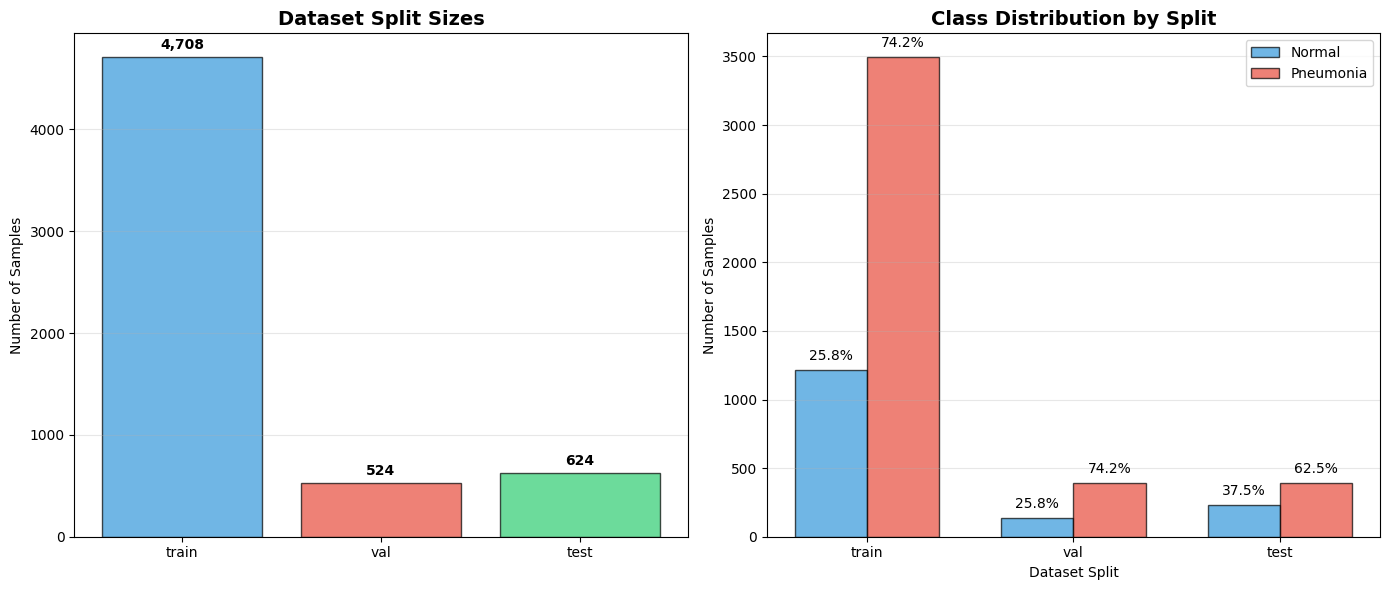

In [6]:
# Analyze dataset distribution for class imbalance considerations
print("Analyzing dataset distribution...")
dataset_splits = explore_dataset_splits(train_loader, val_loader, test_loader)
print(f"\nDataset Summary: {dataset_splits}")

# Visualize dataset distribution
plot_dataset_distribution(dataset_splits)

> **_The impact of class imbalance_**
> 
> Medical datasets often have class imbalance. This affects optimization because:
> 
> - Models may focus compute on majority class features
> - Batch composition affects memory usage patterns
> - Some optimization techniques (like pruning) may disproportionately affect minority class performance

Sample chest X-ray images:


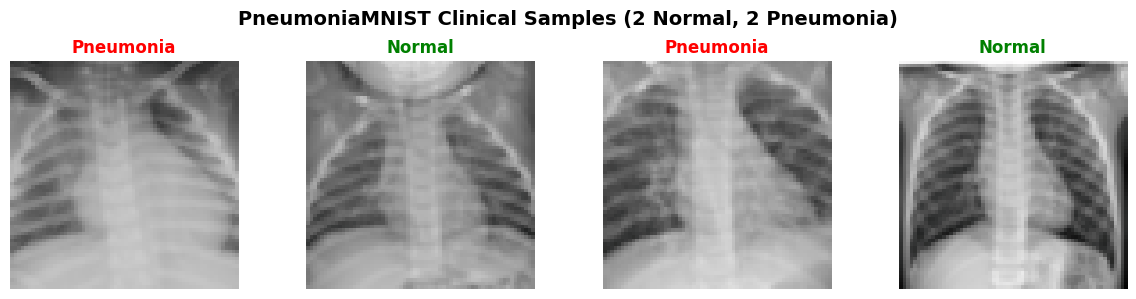

Displayed 4 images: 2 normal, 2 pneumonia


In [7]:
# Visualize sample images to understand data characteristics
print("Sample chest X-ray images:")
visualize_sample_images(train_loader, num_samples=4)

## Step 3: Create and analyze the baseline model
We will use [ResNet-18](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html) as our baseline - a popular choice for medical imaging that balances accuracy and efficiency.

The original model structure is architected for ImageNet (1000 classes), so we modify the model with a custom head to support our new classification task.

In [8]:
# Create the baseline ResNet-18 model
print("Creating ResNet-18 baseline model...")

baseline_model = create_baseline_model(
    num_classes=CONFIG['num_classes'], 
    input_size=CONFIG['image_size'], 
    pretrained=False  # Training from scratch for fair optimization comparison
)
baseline_model = baseline_model.to(device)

print(f"Baseline model created and deployed to {device}")
print(f"   Architecture: {baseline_model.architecture_name}")

Creating ResNet-18 baseline model...
Baseline model created and deployed to cuda
   Architecture: ResNet-18-Adaptive


In [9]:
# Get model information
model_info = get_model_info(baseline_model)

print(f"\nModel Information:")
print(f"   Architecture: {model_info['architecture']}")
print(f"   Total Parameters: {model_info['total_parameters']:,}")
print(f"   Model Size: {model_info['model_size_mb']:.1f} MB")
print(f"   Input Size: {model_info['input_size']}x{model_info['input_size']}")

# Analyze layer composition 
layer_breakdown = model_info['layer_breakdown']
print(f"\nLayer Composition:")
print(f"   Convolution Layers: {layer_breakdown['conv_layers']['count']} ({layer_breakdown['conv_layers']['total_params']:,} params)")
print(f"   Linear Layers: {layer_breakdown['linear_layers']['count']} ({layer_breakdown['linear_layers']['total_params']:,} params)")
print(f"   Normalization Layers: {layer_breakdown['norm_layers']['count']}")
print(f"   Activation Types: {', '.join(layer_breakdown['activation_layers']['types'])}")

# Get parameter distribution
if 'parameter_distribution' in layer_breakdown:
    param_dist = layer_breakdown['parameter_distribution']
    print(f"\nParameter Distribution:")
    print(f"   Convolution: {param_dist['conv_percentage']:.2f}%")
    print(f"   Linear: {param_dist['linear_percentage']:.2f}%")


Model Information:
   Architecture: ResNet-18-Adaptive
   Total Parameters: 11,177,538
   Model Size: 42.6 MB
   Input Size: 64x64

Layer Composition:
   Convolution Layers: 20 (11,166,912 params)
   Linear Layers: 1 (1,026 params)
   Normalization Layers: 20
   Activation Types: ReLU

Parameter Distribution:
   Convolution: 99.99%
   Linear: 0.01%


In [10]:
# Display the model architecture
summary(baseline_model, input_size=(3, CONFIG["image_size"], CONFIG["image_size"]))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

> **_Brainstorming time: Optimizations by layer type_**
> 
> Try to remember from the course, which architectural optimizations most benefit each layer type? Looking at the layer composition, our model is convolution-heavy - this is your starting point!

## Step 4: Train and evaluate baseline model
Now, we define the baseline model and evaluate its performance on key accuracy metrics - all future optimizations should maintain a similar clinical performance standard.

Establishing robust baseline metrics is crucial for medical AI. Any optimization must preserve clinical safety while improving computational efficiency.

Starting baseline model training for pneumonia detection...
   Config: 10 epochs, lr=0.0003, wd=0.0001


   Epoch  1: Train Acc  92.0% | Val Acc  89.3% | Train Loss 0.2116 | Val Loss 0.3036 | LR 0.000300
      New best model saved (Val Acc: 89.3%)


   Epoch  2: Train Acc  95.9% | Val Acc  95.2% | Train Loss 0.1222 | Val Loss 0.1288 | LR 0.000300
      New best model saved (Val Acc: 95.2%)


   Epoch  3: Train Acc  96.1% | Val Acc  96.8% | Train Loss 0.1087 | Val Loss 0.0870 | LR 0.000300
      New best model saved (Val Acc: 96.8%)


   Epoch  4: Train Acc  97.9% | Val Acc  97.7% | Train Loss 0.0588 | Val Loss 0.0671 | LR 0.000030
      New best model saved (Val Acc: 97.7%)


...

   Epoch  6: Train Acc  99.0% | Val Acc  97.3% | Train Loss 0.0326 | Val Loss 0.0709 | LR 0.000030


   Epoch  7: Train Acc  99.2% | Val Acc  98.3% | Train Loss 0.0288 | Val Loss 0.0598 | LR 0.000003
      New best model saved (Val Acc: 98.3%)


   Epoch  8: Train Acc  99.3% | Val Acc  97.9% | Train Loss 0.0209 | Val Loss 0.0585 | LR 0.000003


   Epoch  9: Train Acc  99.4% | Val Acc  97.9% | Train Loss 0.0196 | Val Loss 0.0571 | LR 0.000003


   Epoch 10: Train Acc  99.2% | Val Acc  98.1% | Train Loss 0.0232 | Val Loss 0.0586 | LR 0.000000
     Early stopping triggered after 10 epochs (patience: 3)
Training completed! Best validation accuracy: 98.28%


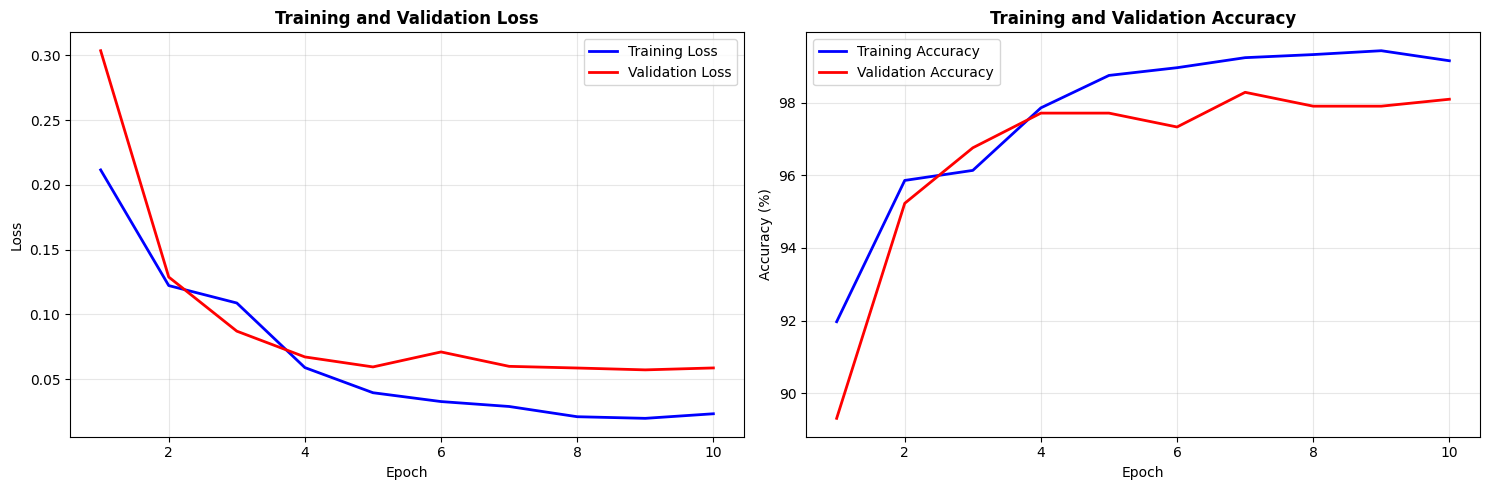


Training Summary:
   Best Validation Accuracy: 98.3%
   Total Epochs: 10
   Final Training Accuracy: 99.2%
   Final Validation Accuracy: 98.1%


In [11]:
# Training configuration
TRAINING_CONFIG = {
    'num_epochs': 10,           # Sufficient for convergence analysis
    'learning_rate': 0.0003,    # Conservative rate for stable training
    'lr_step_size': 3,          # Learning rate decay schedule
    'weight_decay': 1e-4,       # Regularization for generalization
    'patience': 3               # Early stopping for efficiency
}

# Train the model
baseline_model, training_history = train_baseline_model(
    baseline_model, train_loader, val_loader, device, TRAINING_CONFIG
)

# Plot training curves with analysis
plot_training_history(training_history)

> **Training insights: What does the training history tell us?**
> 
> The initial low validation accuracy is due to extreme overfitting due to the small dataset size in comparison to the model's parameter size. The presence of early plateaus and fast convergence also highlight that the architecture has high representational power - we can likely apply aggressive optimization without accuracy degradation.

In [12]:
# Evaluate model performance with multiple thresholds 
print(f"Running eval benchmark on {dataset_splits['test']['total']} test samples ...")
eval_results = evaluate_with_multiple_thresholds(baseline_model, test_loader, device, [0.4, 0.7])

Running eval benchmark on 624 test samples ...

Evaluating with threshold 0.4:
Clinical Evaluation Results (threshold: 0.400):
   Accuracy:  86.5%
   Precision: 82.4% (PPV - Positive Predictive Value)
   Recall:    99.7% (Sensitivity)
   F1 Score:  90.3%
   AUC-ROC:   0.965

Confusion Matrix Analysis:
   True Negatives (Normal correctly identified):     151
   False Positives (Normal misclassified):            83
   False Negatives (Pneumonia missed):                 1
   True Positives (Pneumonia correctly detected):   389

Clinical Performance Interpretation:
   Sensitivity (True Positive Rate):     99.7% (detects 99.7% of pneumonia cases)
   Specificity (True Negative Rate):     64.5% (correctly identifies 64.5% of normal cases)
   PPV (Positive Predictive Value):      82.4% (when model predicts pneumonia, it's correct 82.4% of time)
   NPV (Negative Predictive Value):      99.3% (when model predicts normal, it's correct 99.3% of time)

Clinical Significance:
   False Negative Rate:

> **Clinical threshold selection**
>
> Different thresholds optimize for different clinical scenarios. Lower thresholds (0.4) maximize sensitivity for screening, while higher thresholds (0.7) balance precision and recall for diagnostic confirmation.

## Step 5: Profile baseline model for latency, throughput, and memory usage

Comprehensive performance profiling forms the foundation of our optimization strategy. We will measure all key metrics that impact multi-tenant deployment.

In [13]:
# Initialize performance profiler
profiler = PerformanceProfiler(device=str(device))
print(f"Performance profiler initialized for {device}")

# Get sample batch for profiling
sample_images, sample_labels = get_sample_batch(val_loader)
sample_images = sample_images.to(device)
sample_labels = sample_labels.to(device)

print(f"\nSample batch for profiling:")
print(f"   Batch shape: {sample_images.shape}")
print(f"   Memory usage: {sample_images.numel() * sample_images.element_size() / 1024**2:.1f} MB")

Performance profiler initialized for cuda

Sample batch for profiling:
   Batch shape: torch.Size([32, 3, 64, 64])
   Memory usage: 1.5 MB


In [14]:
# Profile inference timing
print("Profiling inference timing...")

timing_results = profiler.profile_inference_time(
    model=baseline_model,
    input_tensor=sample_images,
    num_runs=100,       # Sufficient for statistical significance
    warmup_runs=10      # GPU warmup for consistent measurements
)

print(f"\nTiming Results:")
print(f"   Single Sample Latency: {timing_results['single_sample_ms']:.2f} ms")
print(f"   (Single) Batch Throughput: {timing_results['throughput_samples_per_sec']:.1f} samples/sec")
print(f"   Batch Latency: {timing_results['batch_total_ms']:.2f} ms")
print(f"   Batch Throughput: {timing_results['batch_throughput_samples_per_sec']:.1f} samples/sec")
print(f"   Mean Inference Time: {timing_results['mean_ms']:.2f} ms")
print(f"   95th Percentile: {timing_results['p95_ms']:.2f} ms")
print(f"   Standard Deviation: {timing_results['std_ms']:.2f} ms")

Profiling inference timing...

Timing Results:
   Single Sample Latency: 1.82 ms
   (Single) Batch Throughput: 549.8 samples/sec
   Batch Latency: 8.39 ms
   Batch Throughput: 3816.0 samples/sec
   Mean Inference Time: 1.82 ms
   95th Percentile: 2.35 ms
   Standard Deviation: 0.24 ms


> **Latency vs throughput trade-offs**
>
> Single sample latency measures real-time diagnostic speed, while batch throughput indicates multi-tenant efficiency. Both metrics are crucial for different deployment scenarios.

In [15]:
# Profile FLOPs for computational efficiency analysis
flops_results = profiler.profile_flops(
    model=baseline_model, 
    input_tensor=sample_images
)

if 'error' in flops_results:
    print(f"FLOPs calculation failed: {flops_results['error']}")
else:
    print(f"\nFLOPs Results:")
    print(f"   Total: {flops_results['total_gflops']:.2f} GFLOPs")
    print(f"   Per Sample: {flops_results['gflops_per_sample']:.2f} GFLOPs")
    if 'module_percentage' in flops_results and flops_results['module_percentage']:
        print(f"\n   Top Operations (by FLOPs):")
        for module, percentage in list(flops_results['module_percentage'].items())[:5]:
            gflops = flops_results['module_breakdown_gflops'][module]
            print(f"     {module}: {percentage:.1f}% ({gflops:.2f} GFLOPs)")

Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::add_ encountered 8 time(s)



FLOPs Results:
   Total: 58.21 GFLOPs
   Per Sample: 1.82 GFLOPs

   Top Operations (by FLOPs):
     conv: 99.7% (58.03 GFLOPs)
     batch_norm: 0.3% (0.16 GFLOPs)
     upsample_bilinear2d: 0.0% (0.02 GFLOPs)
     adaptive_avg_pool2d: 0.0% (0.00 GFLOPs)
     linear: 0.0% (0.00 GFLOPs)


In [16]:
# Profile GPU memory usage
print("Profiling GPU memory usage...")

memory_results = profiler.profile_memory_usage(
    model=baseline_model,
    input_tensor=sample_images
)

if 'error' not in memory_results:
    print(f"\nMemory Results:")
    print(f"   Peak GPU Memory: {memory_results['peak_memory_mb']:.1f} MB")
    print(f"   Memory Increase: {memory_results['memory_increase_mb']:.1f} MB")
    
    # Component breakdown
    if 'component_breakdown' in memory_results:
        components = memory_results['component_breakdown']
        print(f"\nMemory Component Breakdown:")
        for component, usage in components.items():
            print(f"   {component.replace('_', ' ').title()}: {usage:.1f} MB")
else:
    print(f"WARNING: Memory profiling error: {memory_results['error']}")
    memory_results = {}

Profiling GPU memory usage...

Memory Results:
   Peak GPU Memory: 318.2 MB
   Memory Increase: 214.4 MB

Memory Component Breakdown:
   Model Parameters Mb: 42.6 MB
   Input Tensor Mb: 1.5 MB
   Output Tensor Mb: 0.0 MB
   Activations Mb: 212.9 MB


> **_Did you notice? A major optimization opportunity hiding in plain sight!_**
> 
> Look carefully at the model summary above. Something doesn't add up with our input/output dimensions...
> 
> Compare the input size we are feeding (64x64) with the first convolution layer's output size. The first Conv2d layer shows output `[-1, 64, 112, 112]` but our input is only 64x64. Where are those extra pixels coming from? Complete the TODO below to find out.
> 
> *Optimization opportunity:* This might be your biggest single optimization win, in both speed and memory usage! Keep this insight in mind as you analyze the profiling results below.

In [17]:
# Inspect the baseline model's forward method using `inspect.get_source()`
print("Manually inspect the ResNetBaseline forward method:")
baseline_model_forward = inspect.getsource(baseline_model.forward)
print(baseline_model_forward)

print("\nDiscussion questions:")
print("1. What happens when height != self.target_size? What is self.target_size set to?") 
print("2. How much computational and memory overhead does F.interpolate add? (Hint: Compare 64x64 vs 224x224 pixel counts)")
print("3. Is this interpolation necessary for pneumonia detection, or just a legacy from ImageNet pretraining?")

Manually inspect the ResNetBaseline forward method:
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass with adaptive input interpolation for variable input sizes.
        
        Automatically handles input size adaptation to leverage ImageNet pretrained
        features optimally. Critical for medical imaging where input sizes may vary
        across different acquisition protocols.
        
        Args:
            x: Input tensor of shape (batch_size, channels, height, width)
            
        Returns:
            Output logits of shape (batch_size, num_classes) for classification
            
        Note:
            Bilinear interpolation maintains spatial relationships in medical images
            while adapting to the expected ImageNet input size for optimal
            pretrained feature utilization.
            
        Example:
            >>> model = ResNetBaseline()
            >>> input_tensor = torch.randn(8, 3, 28, 28)  # Vari

In [18]:
# Detailed PyTorch profiler
print("Running detailed PyTorch profiler...")

detailed_results = profiler.profile_with_pytorch_profiler(
    model=baseline_model,
    input_tensor=sample_images,
    num_steps=10        # Sufficient for operation breakdown analysis
)

if 'error' not in detailed_results:
    print(f"\nOperation Breakdown:")
    op_breakdown = detailed_results['operation_breakdown']
    
    # Show top operations for optimization targeting
    sorted_ops = sorted(op_breakdown.items(), key=lambda x: x[1], reverse=True)
    for op_type, percentage in sorted_ops:
        if percentage > 1:  # Only show operations > 1%
            print(f"   {op_type.replace('_', ' ').title()}: {percentage:.1f}%")
else:
    print(f"WARNING: Detailed profiling error: {detailed_results['error']}")
    detailed_results = {}

Running detailed PyTorch profiler...


STAGE:2026-01-14 16:48:48 168028:168028 ActivityProfilerController.cpp:314] Completed Stage: Warm Up
STAGE:2026-01-14 16:48:48 168028:168028 ActivityProfilerController.cpp:320] Completed Stage: Collection
STAGE:2026-01-14 16:48:48 168028:168028 ActivityProfilerController.cpp:324] Completed Stage: Post Processing



Operation Breakdown:
   Convolution Ops: 45.8%
   Normalization Ops: 29.8%
   Other Ops: 14.4%
   Activation Ops: 4.2%
   Matrix Multiply Ops: 3.6%
   Pooling Ops: 2.1%


## Step 6: Visualize and save baseline model's performance

Comprehensive visualization helps understand optimization opportunities and track progress across optimization experiments.

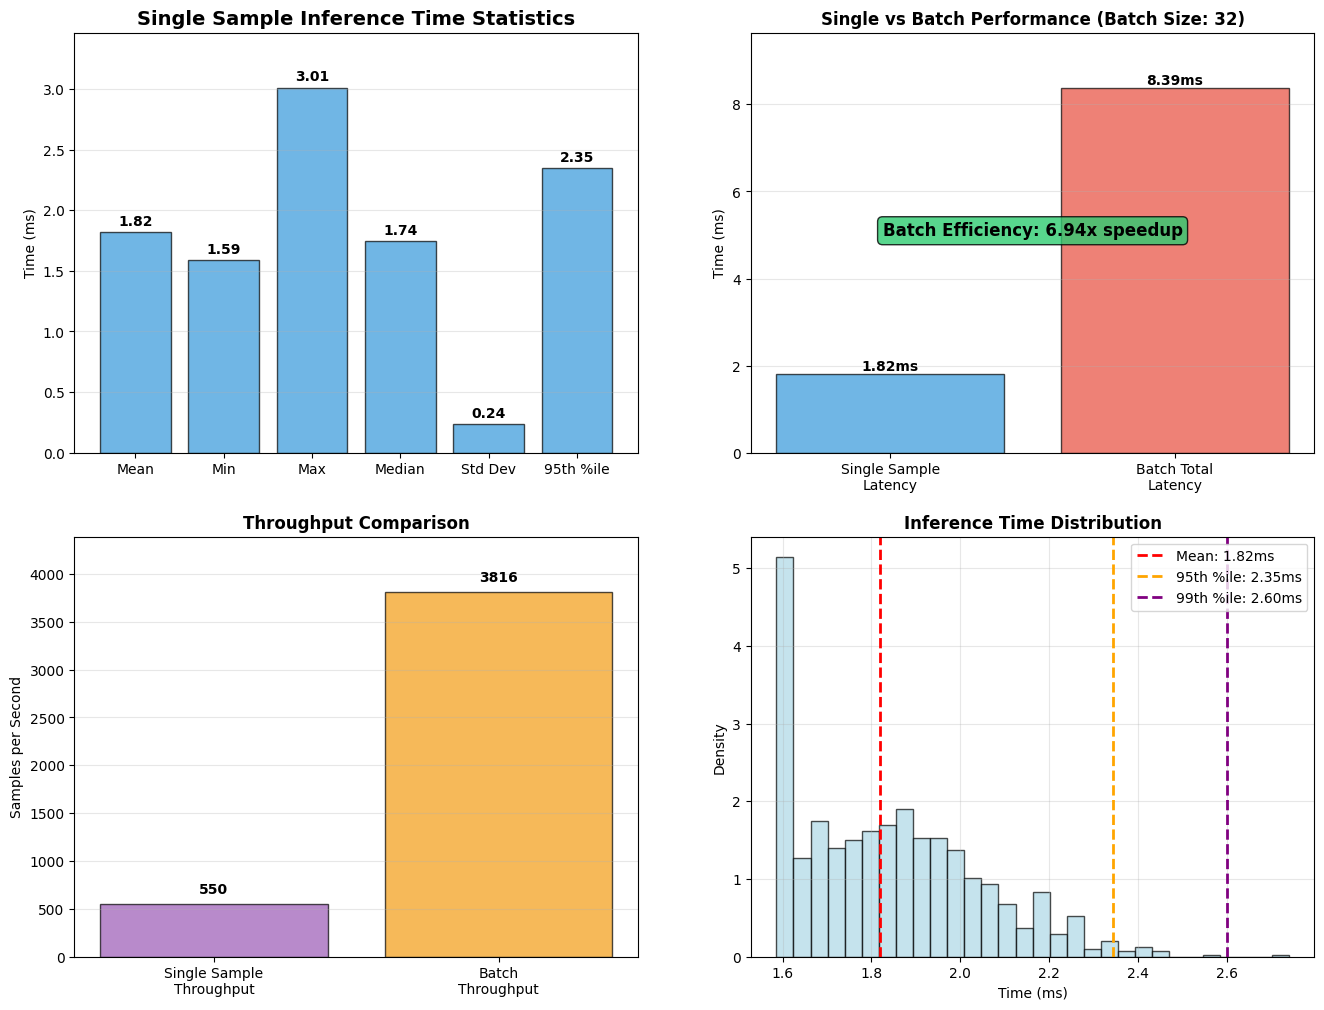

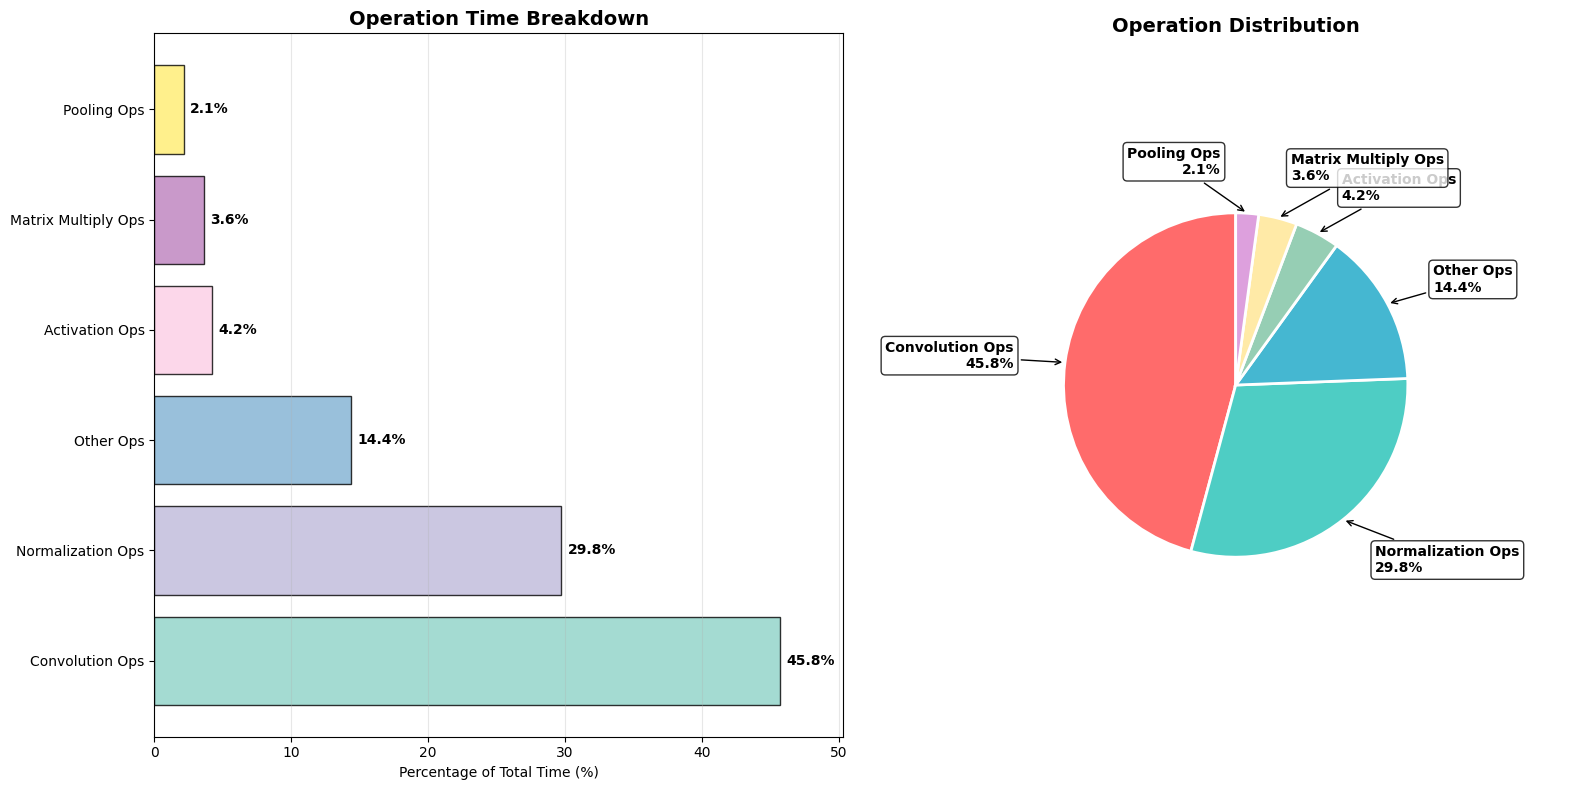

In [19]:
# Visualize performance profile
plot_performance_profile(timing_results)

# Visualize operation breakdown
if detailed_results and 'operation_breakdown' in detailed_results:
    plot_operation_breakdown(detailed_results['operation_breakdown'])
else:
    print("WARNING: Operation breakdown visualization not available")

In [20]:
# Compile baseline results for optimization notebooks
baseline_results = {
    'model_name': 'ResNet-18 Baseline',
    'architecture': model_info['architecture'],
    'total_parameters': model_info['total_parameters'],
    'model_size_mb': model_info['model_size_mb'],
    'config': CONFIG,
    'eval_results': eval_results,
    'timing': timing_results,
    'flops': flops_results,
    'memory': memory_results,
    'operation_breakdown': detailed_results['operation_breakdown'],
    'model_info': model_info,
    'dataset_info': dataset_info,
    'parameter_breakdown': count_parameters_by_type(baseline_model)
}

# Ensure results directory exists
results_dir = '../results'
os.makedirs(results_dir, exist_ok=True)

# Save baseline results
with open(f'{results_dir}/baseline_results.pkl', 'wb') as f:
    pickle.dump(baseline_results, f)

print("Baseline results saved to 'baseline_results.pkl' in the `results/` folder")
print("   This will be used for comparison in optimization notebooks.")

Baseline results saved to 'baseline_results.pkl' in the `results/` folder
   This will be used for comparison in optimization notebooks.


> **Brainstorming time!**
> 
> Based on your profiling results above, analyze the following:
> 
> 1. **Primary bottleneck**: What is the main performance bottleneck - compute time, memory usage, or data transfer?
> 
> 2. **Operation analysis**: Which types of operations (convolution, linear, activation) consume the most time? What percentage?
> 
> 3. **Memory patterns**: How much memory does the model use during inference? What contributes most to memory usage?
> 
> 4. **Optimization priority**: Based on the profiling data, which optimization techniques would you prioritize:
>    - Architecture modifications (channel reduction, efficient blocks)
>    - Precision optimization (mixed precision, quantization)
>    - Hardware acceleration (TensorRT for GPU, ...)
>   
>    _IMPORTANT:_ Did you discover the major inefficiency we hinted at earlier? How much improvement could removing the 64→224 interpolation provide?

---

## Step 7: Analyze optimization opportunities

Now that we have established the baseline performance, it's time for you to conduct a deeper analysis that will guide the optimization strategy. This section contains **two focused analysis checkpoints**:

1. **Architecture optimization analysis** - Identify specific opportunities in the ResNet-18 architecture
2. **Deployment optimization analysis** - Understand hardware acceleration and deployment strategies

Complete these analysis checkpoints to develop your optimization roadmap!

### Analysis checkpoint 1: Architecture optimization opportunities

**Task:** Analyze the ResNet-18 architecture to identify the **top 2 optimization opportunities** from the techniques covered in the course. Available techniques to consider include:
- Grouped convolutions
- Depth-wise separable convolutions
- Inverted residuals with linear bottlenecks
- Low-rank factorization
- Channel organization strategies _(NOTE: this is a hybrid optimization between architecture and hardware)_
- Parameter sharing / weight tying

Feel free to skip programmatic analysis of techniques which you deem to be non-applicable or less performant, but provide an explanation here or in the notebook's final markdown cell.

**IMPORTANT:** Don't forget to also analyze the potential of interpolation removal from the model's forward method!

#### Recommended strategic analysis approach

Calculate the expected impact of applying each technique on parameter reduction programmatically to simplify follow-up analysis. Consider how parameter reduction / architectural improvements for each technique correlate with memory size (activation vs parameters), FLOPs, latency, throughput, and sensitivity to estimate optimization opportunity. HINTS are in each function's signature.

To populate the analysis dictionary with estimated optimiation opportunity, you can either:
1. Programmatically calculate optimization opportunity from parameter reduction and rule-of-thumb
2. Directly add the expected value in the analysis entries, and add a one-line explanation of the value selected as an in-line comment.

In [21]:
## Implement logic for each single technique analysis

def analyze_grouped_conv_potential(model, sample_input_shape=(3, CONFIG["image_size"], CONFIG["image_size"]), groups=2):
    """
    TODO: Analyze which convolution layers could benefit from grouped convolutions.

    HINT: Look for standard convolutions with kernel_size > 1 and sufficient channels that are divisible by groups
    
    Memory impact: Note that parameter memory is only ~13% of total memory in ResNet-18
    FLOP improvements: Update the `in_ch × out_ch × kernel²` calculation for standard conv to account for `groups` division
    Speedup: Proportional to FLOP reduction, but may have overhead from grouped operations on **parallel hardware**
    Throughput: Can be limited by memory bandwidth and **hardware utilization** patterns for grouped operations.
    
    Also, note that, some backends (like CUDA/CUDNN) may require specific memory formats (e.g., channels_last) and mixed precision to unlock maximum throughput for grouped convolutions.
    This is a known issue: https://discuss.pytorch.org/t/performing-convolutions-in-groups-but-not-grouped-convolution/59412/27
    """
    # Initialize analysis structure (feel free to skip any entries you don't want to programmatically calculate)
    analysis = {
        'technique': 'Grouped Convolutions',
        'groups': groups,
        'candidate_layers': [],
        'total_candidates': 0,
        'avg_flop_reduction_percent': 0,
        'avg_param_reduction_percent': 0,
        'estimated_speedup': 1.0,
        'estimated_memory_reduction_mb': 0,
        'estimated_throughput_samples_sec': timing_results['throughput_samples_per_sec'],
        'throughput_improvement_percent': 0,
        'sensitivity_risk': ''
    }

    candidate_layers = []
    total_params = 0
    saved_params = 0
    
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            params = module.in_channels * module.out_channels * module.kernel_size[0] * module.kernel_size[1]
            total_params += params
            
            # Check that both in_channels and out_channels are divisible by groups for valid grouped convolution
            if (module.kernel_size[0] > 1 and module.groups == 1 and 
                module.in_channels % groups == 0 and module.out_channels % groups == 0):
                candidate_layers.append(name)
                current_params = params
                grouped_params = params // groups
                saved_params += (current_params - grouped_params)
    
    analysis['candidate_layers'] = candidate_layers
    analysis['total_candidates'] = len(candidate_layers)
    
    if total_params > 0:
        analysis['avg_param_reduction_percent'] = (saved_params / total_params) * 100
        analysis['avg_flop_reduction_percent'] = analysis['avg_param_reduction_percent'] 
        
    conv_coverage = 0.9 
    hardware_efficiency_factor = 0.7
    flop_reduction_ratio = analysis['avg_flop_reduction_percent'] / 100.0
    
    if flop_reduction_ratio > 0:
        analysis['estimated_speedup'] = 1 / (1 - flop_reduction_ratio * conv_coverage * hardware_efficiency_factor)
        
    analysis['throughput_improvement_percent'] = (analysis['estimated_speedup'] - 1.0) * 100
    analysis['estimated_throughput_samples_sec'] *= analysis['estimated_speedup']
    analysis['sensitivity_risk'] = 'Low - Standard technique'
    
    return analysis

def analyze_depthwise_separable_potential(model, sample_input_shape=(3, CONFIG["image_size"], CONFIG["image_size"])):
    """
    TODO: Analyze which convolution layers could benefit from depthwise separable convolutions.

    HINT: Look for standard convolutions with kernel_size > 1 and sufficient channels (e.g., >=16)
    
    Memory impact: Note that parameter memory is only ~13% of total memory in ResNet-18
    FLOP improvements: Update the `in_ch × out_ch × kernel²` calculation for standard conv to account for two layers now
    Speedup: Proportional to FLOP reduction, but can be penalized (e.g., ~0.6x) due to memory-access overhead, as many small operations may not fully utilize hardware parallelism
    Throughput: Directly scales with speedup estimates for batch processing scenarios
    """
    analysis = {
        'technique': 'Depthwise Separable Convolutions',
        'candidate_layers': [],
        'total_candidates': 0,
        'avg_flop_reduction_percent': 0,
        'avg_param_reduction_percent': 0,
        'estimated_speedup': 1.0,
        'estimated_memory_reduction_mb': 0,
        'estimated_throughput_samples_sec': timing_results['throughput_samples_per_sec'],
        'throughput_improvement_percent': 0,
        'sensitivity_risk': ''
    }

    candidate_layers = []
    total_params = 0
    saved_params_total = 0

    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            std_params = module.in_channels * module.out_channels * module.kernel_size[0] * module.kernel_size[1]
            total_params += std_params
            
            if module.kernel_size[0] > 1 and module.in_channels >= 16:
                # Calculate depthwise + pointwise separable parameters
                dw_params = module.in_channels * module.kernel_size[0] * module.kernel_size[1]
                pw_params = module.in_channels * module.out_channels
                sep_params = dw_params + pw_params
                
                # Only count as candidate if separable conv actually saves parameters
                param_savings = std_params - sep_params
                if param_savings > 0:
                    candidate_layers.append(name)
                    saved_params_total += param_savings
    
    analysis['candidate_layers'] = candidate_layers
    analysis['total_candidates'] = len(candidate_layers)
    
    if total_params > 0:
        analysis['avg_param_reduction_percent'] = (saved_params_total / total_params) * 100
        analysis['avg_flop_reduction_percent'] = analysis['avg_param_reduction_percent']

    theoretical_speedup = 1.0
    if analysis['avg_flop_reduction_percent'] > 0:
        theoretical_speedup = 1 / (1 - (analysis['avg_flop_reduction_percent'] / 100.0) * 0.9)
    
    analysis['estimated_speedup'] = theoretical_speedup * 0.6
    analysis['throughput_improvement_percent'] = (analysis['estimated_speedup'] - 1.0) * 100
    analysis['estimated_throughput_samples_sec'] *= analysis['estimated_speedup']
    analysis['sensitivity_risk'] = 'Medium - Significant structural change'

    return analysis

def analyze_inverted_residuals_potential(model):
    """
    TODO: Analyze potential for inverted residual blocks (expand -> depthwise -> project).
    Hint: Look for 3x3 convolutions that expand channels (MobileNet-style patterns)
    
    Memory impact: Can reduce average memory but may increase peak during expansion phase
    FLOP improvements: Layer-specific FLOP savings through efficient bottleneck patterns
    Speedup: 1.1x to 1.2x based on candidate count and architecture structure (variable)
    Throughput: Modest improvements proportional to architectural efficiency gains
    """
    analysis = {
        'technique': 'Inverted Residual Blocks',
        'residual_candidates': [],
        'total_candidates': 0,
        'avg_flop_reduction_percent': 0,
        'estimated_speedup': 1.0,
        'estimated_memory_reduction_mb': 0,
        'estimated_throughput_samples_sec': timing_results['throughput_samples_per_sec'],
        'throughput_improvement_percent': 0,
        'sensitivity_risk': ''
    }
    
    candidates = []
    for name, module in model.named_modules():
         if isinstance(module, nn.Conv2d) and module.kernel_size[0] == 3:
             candidates.append(name)
             
    analysis['residual_candidates'] = candidates
    analysis['total_candidates'] = len(candidates)
    
    analysis['estimated_speedup'] = 1.15
    analysis['avg_flop_reduction_percent'] = 30
    analysis['throughput_improvement_percent'] = 15
    analysis['estimated_throughput_samples_sec'] *= 1.15
    analysis['sensitivity_risk'] = 'Medium - Architecture change'
    
    return analysis

def analyze_lowrank_factorization_potential(model, batch_size=32):
    """
    TODO: Analyze large linear layers that could benefit from low-rank factorization.
    Hint: Focus on layers where input_features * output_features > 10000

    Memory impact: Reduces parameter memory through low-rank matrix decomposition
    FLOP improvements: Matrix multiply FLOPs reduced proportionally to rank reduction --> batch_size × (in_features × rank + rank × out_features)
    Speedup: 1.0x–1.4x depending on layers present, but penalized due to factorization overhead
    Throughput: Limited improvement for ResNet-18 due to small linear layers, but scales with any FLOP reductions achieved
    """
    analysis = {
        'technique': 'Low-Rank Factorization',
        'factorization_candidates': [],
        'total_candidates': 0,
        'avg_param_reduction_percent': 0,
        'avg_flop_reduction_percent': 0,
        'estimated_speedup': 1.0,
        'estimated_memory_reduction_mb': 0,
        'estimated_throughput_samples_sec': timing_results['throughput_samples_per_sec'],
        'throughput_improvement_percent': 0,
        'sensitivity_risk': ''
    }
    
    candidates = []
    total_linear_params = 0
    saved_params = 0
    
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            params = module.in_features * module.out_features
            total_linear_params += params
            
            if params > 10000:
                candidates.append(name)
                rank_ratio = 0.25
                rank = int(min(module.in_features, module.out_features) * rank_ratio)
                factorized_params = (module.in_features * rank) + (rank * module.out_features)
                saved_params += (params - factorized_params)
                
    analysis['factorization_candidates'] = candidates
    analysis['total_candidates'] = len(candidates)
    
    # Calculate actual parameter and FLOP reduction based on identified candidates
    if total_linear_params > 0 and saved_params > 0:
        analysis['avg_param_reduction_percent'] = (saved_params / total_linear_params) * 100
        # FLOP reduction is proportional to parameter reduction for linear layers
        analysis['avg_flop_reduction_percent'] = analysis['avg_param_reduction_percent']
        
        # Estimate speedup: limited by linear layer contribution to total compute (small for ResNet-18)
        linear_compute_fraction = 0.05  # Linear layers are ~5% of total compute in ResNet-18
        flop_reduction_ratio = analysis['avg_flop_reduction_percent'] / 100.0
        analysis['estimated_speedup'] = 1 / (1 - flop_reduction_ratio * linear_compute_fraction * 0.8)  # 0.8 overhead factor
    else:
        # No candidates found - minimal benefit for ResNet-18 with small FC head
        analysis['avg_param_reduction_percent'] = 0.0
        analysis['avg_flop_reduction_percent'] = 0.0
        analysis['estimated_speedup'] = 1.0
        
    analysis['throughput_improvement_percent'] = (analysis['estimated_speedup'] - 1.0) * 100
    analysis['estimated_throughput_samples_sec'] *= analysis['estimated_speedup']
    analysis['sensitivity_risk'] = 'Low - Minimal impact on ResNet-18 due to small FC head'
        
    return analysis

def analyze_channel_organization_potential(model):
    """
    TODO: Analyze channel organization optimizations for hardware efficiency.
    Hint: Look for in-place operation opportunities (architecture optimization) and memory layout optimizations (hardware optimization)
    
    Memory impact: Improved memory access patterns or reduced memory via more efficient channel organization (variable)
    FLOP improvements: No FLOP reduction - same operations, just more efficient execution
    Speedup: 1.05x-1.10x depending on hardware and implementation (variable)
    Throughput: Small but consistent improvements through better hardware utilization patterns
    """
    analysis = {
        'technique': 'Channel Organization (channels_last + in-place ReLU)',
        'inplace_opportunities': {},
        'estimated_speedup': 1.0,
        'estimated_memory_reduction_mb': 0,
        'avg_flop_reduction_percent': 0,
        'estimated_throughput_samples_sec': timing_results['throughput_samples_per_sec'],
        'throughput_improvement_percent': 0,
        'sensitivity_risk': ''
    }
    
    relu_count = 0
    for m in model.modules():
        if isinstance(m, nn.ReLU) and not m.inplace:
            relu_count += 1
            
    analysis['inplace_opportunities'] = {'relu_not_inplace': relu_count}
    
    speedup = 1.2 * (1.0 + relu_count * 0.008)
    
    analysis['estimated_speedup'] = speedup
    analysis['throughput_improvement_percent'] = (speedup - 1.0) * 100
    analysis['estimated_throughput_samples_sec'] *= speedup
    analysis['sensitivity_risk'] = 'None - Purely operational'

    return analysis

def analyze_parameter_sharing_potential(model):
    """
    TODO: Analyze potential for parameter sharing across similar layers.
    Hint: Use convolution-to-total parameter ratio to estimate redundancy potential.
          Higher conv ratio indicates greater opportunity for sharing similar operations.

    Memory impact: Reduces parameter memory footprint directly through weight sharing
    FLOP improvements: Sharing can reduce redundant computation and improve cache locality, but may also introduce overhead
    Speedup: Apply 0.5x multiplier to sharing ratio due to implementation complexity
    Throughput: Conservative improvements due to potential overhead from shared parameter access patterns
    """
    analysis = {
        'technique': 'Parameter Sharing',
        'similar_layer_groups': [],
        'sharing_potential_percent': 0,
        'avg_flop_reduction_percent': 0,
        'estimated_speedup': 1.0,
        'estimated_memory_reduction_mb': 0,
        'estimated_throughput_samples_sec': timing_results['throughput_samples_per_sec'],
        'throughput_improvement_percent': 0,
        'sensitivity_risk': ''
    }
    
    from collections import defaultdict
    shapes = defaultdict(list)
    total_params = 0
    
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            shape = (module.in_channels, module.out_channels, module.kernel_size)
            shapes[shape].append(name)
            total_params += module.in_channels * module.out_channels * module.kernel_size[0] * module.kernel_size[1]
            
    shareable_params = 0
    for shape, layers in shapes.items():
        if len(layers) > 1:
            params_per_layer = shape[0] * shape[1] * shape[2][0] * shape[2][1]
            shareable_params += params_per_layer * (len(layers) - 1)
            analysis['similar_layer_groups'].append(f"{len(layers)} layers of shape {shape}")

    sharing_potential = 0
    if total_params > 0:
        sharing_potential = min(0.25, shareable_params / total_params)
        
    analysis['sharing_potential_percent'] = sharing_potential * 100
    
    # Parameter sharing primarily reduces memory, with minimal FLOP impact
    # Cache locality improvements may provide small speedup
    analysis['avg_flop_reduction_percent'] = sharing_potential * 5  # Conservative: ~5% of sharing potential
    
    speedup = 1.0 + sharing_potential * 0.4
    analysis['estimated_speedup'] = speedup
    analysis['throughput_improvement_percent'] = (speedup - 1.0) * 100
    analysis['estimated_throughput_samples_sec'] *= speedup
    analysis['sensitivity_risk'] = 'High - Reduces model capacity'

    return analysis

def analyze_interpolation_removal_potential(model, sample_input_shape=(3, CONFIG["image_size"], CONFIG["image_size"])):
    """
    TODO: Analyze the potential for removing interpolation overhead by processing images at native resolution.
    HINT: This is the biggest single optimization opportunity! Focus on calculating the computational overhead from 64x64→224x224 interpolation
    
    Memory impact: A % of activtion memory scales with input size reduction (12x theoretical)
    FLOP improvements: Direct 12x reduction in convolution operations
    Speedup: LIMITED by Amdahl's law - a % of the convolution_ops scales with input size, but there are also fixed overheads (FC layers, data loading) that don't scale with input size
    Throughput: Better for batch processing where fixed costs are amortized (make sure to multiply estimate by at least the current batch processing)
    """
    analysis = {
        'technique': 'Interpolation Removal (Native Resolution)',
        'interpolation_size': 224, 
        'original_image_size': CONFIG["image_size"],
        'avg_flop_reduction_percent': 0,
        'estimated_speedup': 1.0,
        'estimated_memory_reduction_mb': 0,
        'estimated_throughput_samples_sec': timing_results['throughput_samples_per_sec'],
        'throughput_improvement_percent': 0,
        'sensitivity_risk': ''
    }

    interpolation_factor = (224 / 64) ** 2
    theoretical_flop_reduction = (1.0 - (1.0 / interpolation_factor)) * 100
    
    analysis['avg_flop_reduction_percent'] = theoretical_flop_reduction
    
    conv_coverage = 0.9
    scalable_portion = conv_coverage * 0.6 
    fixed_portion = 1.0 - scalable_portion
    
    speedup = 1 / (fixed_portion + scalable_portion / interpolation_factor)
    
    analysis['estimated_speedup'] = speedup
    analysis['throughput_improvement_percent'] = (speedup - 1.0) * 100
    analysis['estimated_throughput_samples_sec'] *= speedup
    analysis['sensitivity_risk'] = 'Medium - ImageNet weights trained on 224x224'

    return analysis

In [22]:
# Run the complete architecture optimization analysis with all 5 implemented analysis functions above
def run_architecture_optimization_analysis(model):
    """
    Main function to run all architecture optimization analyses.
    """
    print("Running architecture optimization analysis...")
    
    # Call each analysis function
    depthwise_analysis = analyze_depthwise_separable_potential(model)
    grouped_analysis = analyze_grouped_conv_potential(model)
    inverted_analysis = analyze_inverted_residuals_potential(model)
    lowrank_analysis = analyze_lowrank_factorization_potential(model)
    channel_analysis = analyze_channel_organization_potential(model)
    sharing_analysis = analyze_parameter_sharing_potential(model)
    interpolation_analysis = analyze_interpolation_removal_potential(model)
    
    # Combine all analyses into comprehensive result
    # TODO: Remove any techniques which haven't been analyzed
    optimization_techniques = {
        'grouped_convolutions': {
            'candidate_layers': grouped_analysis['total_candidates'],
            'groups': grouped_analysis['groups'],
            'avg_param_reduction_percent': grouped_analysis['avg_param_reduction_percent'],
            'estimated_speedup': grouped_analysis['estimated_speedup'],
            'avg_flop_reduction_percent': grouped_analysis['avg_flop_reduction_percent'],
            'estimated_memory_reduction_mb': grouped_analysis['estimated_memory_reduction_mb'],
            'throughput_improvement_percent': grouped_analysis['throughput_improvement_percent'],
            'sensitivity_risk': grouped_analysis['sensitivity_risk'],
            'details': grouped_analysis['candidate_layers'][:3]  # Show top 3
        },
        'depthwise_separable': {
            'candidate_layers': depthwise_analysis['total_candidates'],
            'avg_param_reduction_percent': depthwise_analysis['avg_param_reduction_percent'],
            'estimated_speedup': depthwise_analysis['estimated_speedup'],
            'avg_flop_reduction_percent': depthwise_analysis['avg_flop_reduction_percent'],
            'estimated_memory_reduction_mb': depthwise_analysis['estimated_memory_reduction_mb'],
            'throughput_improvement_percent': depthwise_analysis['throughput_improvement_percent'],
            'sensitivity_risk': depthwise_analysis['sensitivity_risk'],
            'details': depthwise_analysis['candidate_layers'][:3]  # Show top 3
        },
        'inverted_residuals': {
            'expansion_candidates': inverted_analysis['total_candidates'],
            'estimated_speedup': inverted_analysis['estimated_speedup'],
            'avg_flop_reduction_percent': inverted_analysis['avg_flop_reduction_percent'],
            'estimated_memory_reduction_mb': inverted_analysis['estimated_memory_reduction_mb'],
            'throughput_improvement_percent': inverted_analysis['throughput_improvement_percent'],
            'sensitivity_risk': inverted_analysis['sensitivity_risk']
        },
        'low_rank_factorization': {
            'candidate_layers': lowrank_analysis['total_candidates'],
            'avg_param_reduction_percent': lowrank_analysis['avg_param_reduction_percent'],
            'estimated_speedup': lowrank_analysis['estimated_speedup'],
            'avg_flop_reduction_percent': lowrank_analysis['avg_flop_reduction_percent'],
            'estimated_memory_reduction_mb': lowrank_analysis['estimated_memory_reduction_mb'],
            'throughput_improvement_percent': lowrank_analysis['throughput_improvement_percent'],
            'sensitivity_risk': lowrank_analysis['sensitivity_risk']
        },
        'channel_organization': {
            'inplace_opportunities': channel_analysis['inplace_opportunities'],
            'estimated_speedup': channel_analysis['estimated_speedup'],
            'avg_flop_reduction_percent': channel_analysis['avg_flop_reduction_percent'],
            'estimated_memory_reduction_mb': channel_analysis['estimated_memory_reduction_mb'],
            'throughput_improvement_percent': channel_analysis['throughput_improvement_percent'],
            'sensitivity_risk': channel_analysis['sensitivity_risk']
        },
        'parameter_sharing': {
            'sharing_potential_percent': sharing_analysis['sharing_potential_percent'],
            'estimated_speedup': sharing_analysis['estimated_speedup'],
            'avg_flop_reduction_percent': sharing_analysis['avg_flop_reduction_percent'],
            'estimated_memory_reduction_mb': sharing_analysis['estimated_memory_reduction_mb'],
            'throughput_improvement_percent': sharing_analysis['throughput_improvement_percent'],
            'sensitivity_risk': sharing_analysis['sensitivity_risk']
        },
        'interpolation_removal': {
            'current_input_size': interpolation_analysis["interpolation_size"],
            'native_input_size': interpolation_analysis["original_image_size"],
            'estimated_speedup': interpolation_analysis['estimated_speedup'],
            'avg_flop_reduction_percent': interpolation_analysis['avg_flop_reduction_percent'],
            'estimated_memory_reduction_mb': interpolation_analysis['estimated_memory_reduction_mb'],
            'throughput_improvement_percent': interpolation_analysis['throughput_improvement_percent'],
            'sensitivity_risk': interpolation_analysis['sensitivity_risk']
        }
    }
    
    return optimization_techniques

# Execute architecture analysis
arch_analysis = run_architecture_optimization_analysis(baseline_model)

# Display results
print(f"\nARCHITECTURE OPTIMIZATION RESULTS:")
for technique, details in arch_analysis.items():
    print(f"\n   {technique.replace('_', ' ').title()}:")
    for key, value in details.items():
        if key != 'details':
            print(f"     {key.replace('_', ' ').title()}: {value}")

Running architecture optimization analysis...

ARCHITECTURE OPTIMIZATION RESULTS:

   Grouped Convolutions:
     Candidate Layers: 16
     Groups: 2
     Avg Param Reduction Percent: 49.187599938102856
     Estimated Speedup: 1.4490273048256563
     Avg Flop Reduction Percent: 49.187599938102856
     Estimated Memory Reduction Mb: 0
     Throughput Improvement Percent: 44.90273048256563
     Sensitivity Risk: Low - Standard technique

   Depthwise Separable:
     Candidate Layers: 16
     Avg Param Reduction Percent: 87.17124304373492
     Estimated Speedup: 2.7847549735462396
     Avg Flop Reduction Percent: 87.17124304373492
     Estimated Memory Reduction Mb: 0
     Throughput Improvement Percent: 178.47549735462397
     Sensitivity Risk: Medium - Significant structural change

   Inverted Residuals:
     Expansion Candidates: 16
     Estimated Speedup: 1.15
     Avg Flop Reduction Percent: 30
     Estimated Memory Reduction Mb: 0
     Throughput Improvement Percent: 15
     Sensiti

> **_Before you move on...brainstorming time!_**
> 
> Based on your architecture analysis results, collect your insights on architectural opportunities
> 
> 1. **Primary bottleneck**: Convolution ops dominate compute (from the profiler, convs are ~50%+ of ops and ~99% of FLOPs). This is expected for ResNet-18, which is convolution-heavy with small FC head. This means we should prioritize optimizations that cut convolution FLOPs (remove 64→224 upsampling, depthwise/grouped convs) over FC-focused methods.
> 
> 2. **Resource trade-offs:** 
>    - **Param reduction**: depthwise separable, grouped convs, low-rank factorization, parameter sharing. These can reduce model size but may affect accuracy if over-applied (especially parameter sharing, which reduces capacity).
>    - **Compute efficiency**: interpolation removal (largest FLOP/memory win), depthwise separable, inverted residuals, and channel organization (memory layout + in-place ReLU). Compute-focused changes can impact accuracy if the representational capacity changes (depthwise/inverted residuals), so careful fine-tuning is required.
> 
> 3. **Optimization priority**: 
>    1) Remove interpolation (biggest immediate FLOP + activation memory win). 
>    2) Depthwise separable convs (large FLOP reduction on conv layers). 
>    3) Channel optimization (channels_last + in-place ReLU for hardware efficiency). 
>    4) Grouped convs (moderate benefit, potentially less GPU-friendly). 
>    5) Inverted residuals or low-rank factorization (higher refactor cost / lower ROI on ResNet-18). 
>    Parameter sharing is lowest priority due to higher clinical risk.
> 
> 4. **Feasibility assessment:** With interpolation removal + depthwise separable + channel optimization, the 3ms target is likely achievable. If still short, hardware acceleration (FP16/TensorRT) or reducing input resolution further would be next steps. Quantization (INT8) is possible but requires careful clinical validation to protect sensitivity.

### Analysis checkpoint 2: Deployment optimization opportunities

**Task:** Analyze deployment characteristics for our reference hardware, with a focus on batch processing trade-offs and mixed precision acceleration.

_Feel free to also add considerations from other hardware optimization techniques, such as leveraging specialized hardware acceleration units (e.g., Tensor Cores, NPUs) and other memory optimization patterns._

In [23]:
### Implement logic for each single technique analysis 

def analyze_mixed_precision_potential(detailed_results):
    """    
    TODO: Analyze mixed precision (FP16) acceleration potential.
    HINTS: These are the key analysis points to focus on:
    - Mixed precision suitability calculation based on operation types (hardware accelerators for FP16 typically target matrix multiplies and convolutions)
    - Research-backed speedup estimates (1.8-2.5x for high coverage)
    - Memory reduction modeling (FP32->FP16 = ~50% reduction)
    - Throughput impact calculation (scales with speedup for batch processing scenarios)
    """
    analysis = {
        'technique': 'Mixed Precision (FP16)',
        'mixed_precision_eligible_ops': 0,
        'mixed_precision_coverage_percent': 0,
        'estimated_speedup': 1.0,
        'estimated_memory_reduction_mb': 0,
        'avg_flop_reduction_percent': 0,
        'estimated_throughput_samples_sec': timing_results['batch_throughput_samples_per_sec'],
        'throughput_improvement_percent': 0,
        'sensitivity_risk': ''
    }

    eligible_keywords = ['conv', 'linear', 'matmul', 'gemm']
    total_ops = 0
    eligible_ops = 0
    
    if detailed_results and 'operation_breakdown' in detailed_results:
        for op, percent in detailed_results['operation_breakdown'].items():
            total_ops += 1
            if any(k in op.lower() for k in eligible_keywords):
                eligible_ops += 1
                
    coverage_percent = 0
    if total_ops > 0:
        coverage_percent = (eligible_ops / total_ops) * 100
        
    analysis['mixed_precision_coverage_percent'] = coverage_percent
    
    estimated_speedup = 1.0
    if coverage_percent > 50:
        estimated_speedup = 1.8 + (coverage_percent - 50) * 0.014
    else:
        estimated_speedup = 1.0 + (coverage_percent / 100.0) * 0.5
        
    analysis['estimated_speedup'] = estimated_speedup
    
    if 'memory' in baseline_results and 'peak_memory_mb' in baseline_results['memory']:
        peak = baseline_results['memory']['peak_memory_mb']
        analysis['estimated_memory_reduction_mb'] = peak * 0.5
        
    analysis['throughput_improvement_percent'] = (estimated_speedup - 1.0) * 100
    analysis['estimated_throughput_samples_sec'] *= estimated_speedup
    analysis['sensitivity_risk'] = 'Low - FP16 usually sufficient'
    
    return analysis

def analyze_batch_processing_scenarios(model, mixed_precision_speedup, sample_input_shape=(1, 3, CONFIG["image_size"], CONFIG["image_size"])):
    """
    TODO: Analyze different deployment scenarios with realistic batch processing logic.
    
    HINT: Focus on finding optimal batch sizes for different use cases (real-time vs throughput) using the profiler.profile_multiple_batch_sizes() function.
    Real-time optimizes for lowest latency per sample, throughput optimizes for maximum samples/sec
    """
    scenarios = {
        'real_time_diagnosis': {
            'optimal_batch_size': 1,
            'current_latency_ms': 0,
            'mixed_precision_latency_ms': 0,
            'use_case': 'Emergency diagnosis, single patient processing'
        },
        'batch_processing': {
            'optimal_batch_size': 32,
            'current_throughput_samples_sec': 0,
            'mixed_precision_throughput_samples_sec': 0,
            'use_case': 'Screening workflows, research processing'
        }
    }
    
    batch_sizes = [1, 4, 8, 16, 32, 64] 

    print("   Profiling multiple batch sizes...")
    batch_results = profiler.profile_multiple_batch_sizes(
        model, sample_input_shape, batch_sizes
    )
    
    best_latency = float('inf')
    best_throughput = 0
    best_bs_latency = 1
    best_bs_throughput = 1
    
    for bs, metrics in batch_results.items():
        # Convert key like "batch_8" -> 8
        if isinstance(bs, str) and bs.startswith('batch_'):
            try:
                bs = int(bs.split('_')[1])
            except ValueError:
                continue

        if isinstance(metrics, dict) and 'error' in metrics:
            continue

        # Unwrap nested timing dict if present
        if isinstance(metrics, dict) and 'timing' in metrics:
            metrics = metrics['timing']

        if not isinstance(metrics, dict):
            continue

        mean_latency = metrics.get('mean_latency_ms', metrics.get('mean_ms'))
        if mean_latency is None:
            continue

        if mean_latency < best_latency:
            best_latency = mean_latency
            best_bs_latency = bs
        
        tp = metrics.get('throughput_samples_per_sec', (1000.0 / mean_latency) * bs)
        if tp > best_throughput:
            best_throughput = tp
            best_bs_throughput = bs
    scenarios['real_time_diagnosis']['optimal_batch_size'] = best_bs_latency
    scenarios['real_time_diagnosis']['current_latency_ms'] = best_latency
    scenarios['real_time_diagnosis']['mixed_precision_latency_ms'] = best_latency / mixed_precision_speedup
    
    scenarios['batch_processing']['optimal_batch_size'] = best_bs_throughput
    scenarios['batch_processing']['current_throughput_samples_sec'] = best_throughput
    scenarios['batch_processing']['mixed_precision_throughput_samples_sec'] = best_throughput * mixed_precision_speedup

    return batch_results, scenarios

Running Deployment Optimization Analysis...
   Profiling multiple batch sizes...


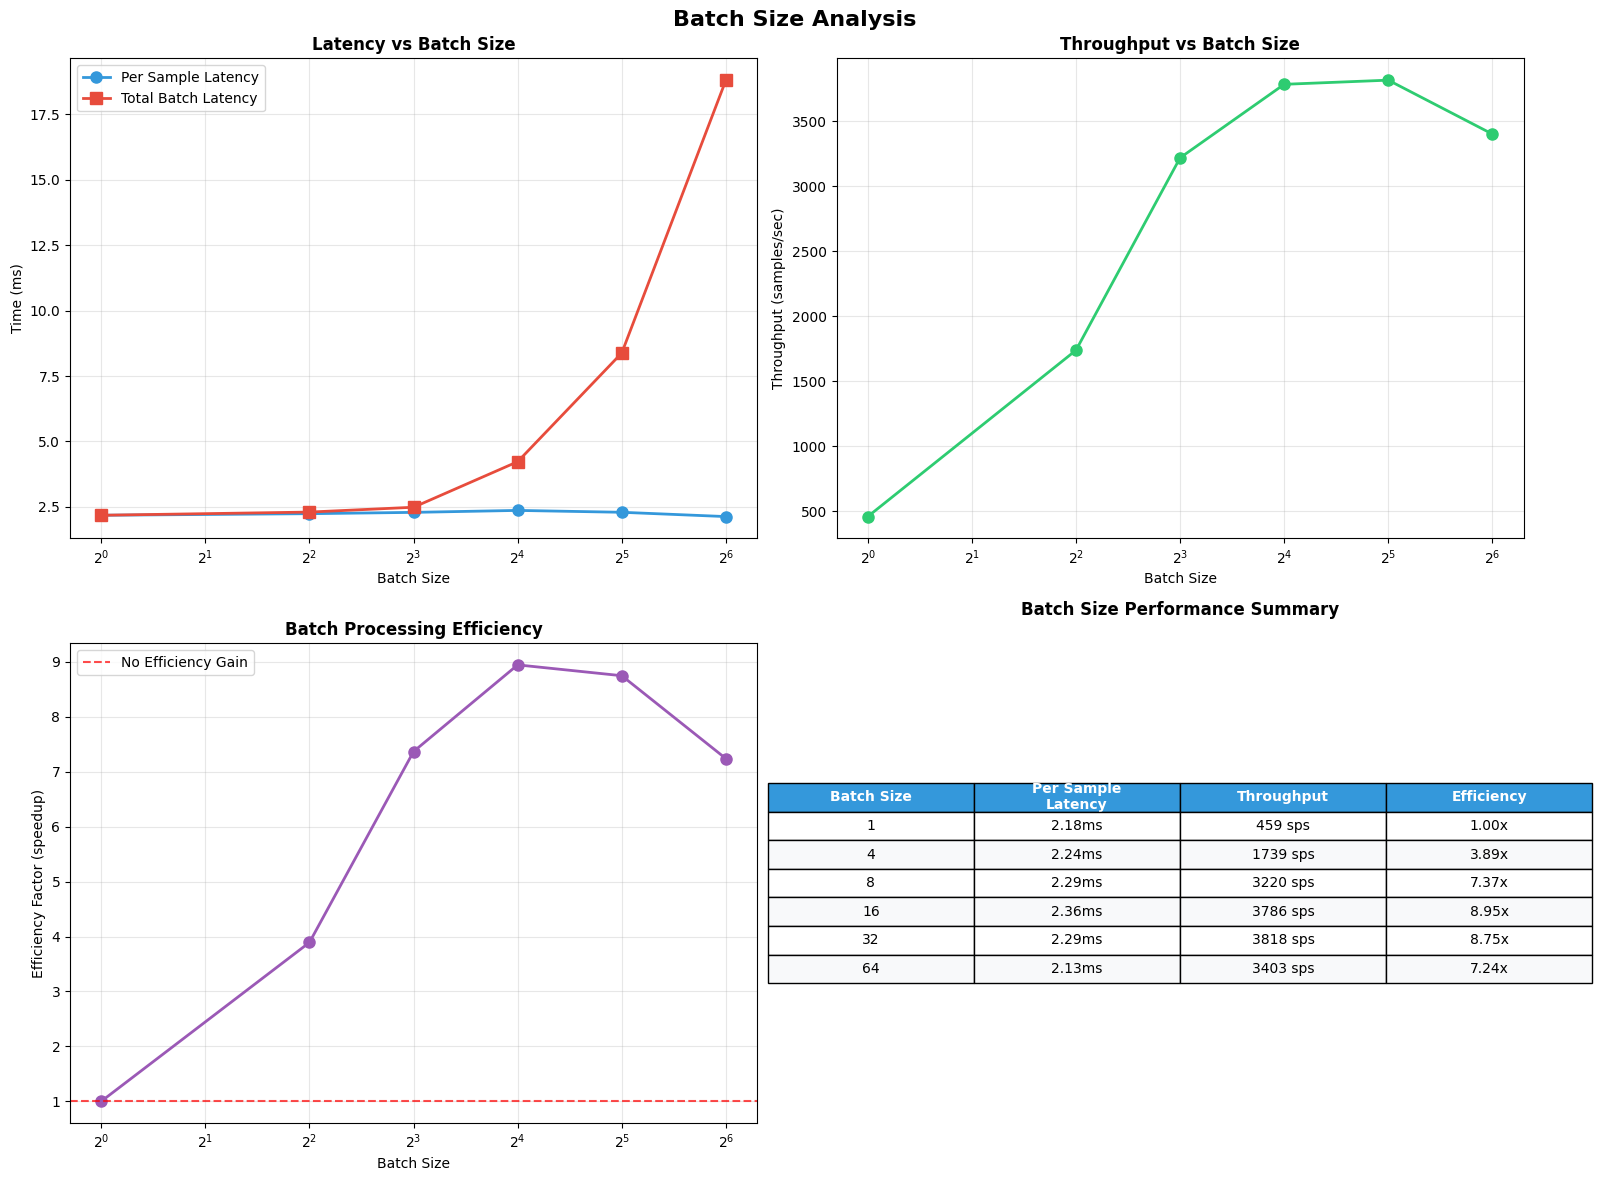


DEPLOYMENT OPTIMIZATION RESULTS:

   Mixed Precision (FP16):
     Tensor Core Eligible: 14.3%
     Estimated FLOP improvements: 0.0%
     Estimated Speedup: 1.1x
     Note: FP16 improves throughput/latency but does not reduce FLOP count; use architectural changes for FLOP reduction.
     Estimated Throughput improvements %: 7.1%
     Estimated Memory Savings: 159.1MB
     Estimated Sensitivity Risk: Low - FP16 usually sufficient

   Deployment Scenarios:
     Real Time Diagnosis:
       Optimal Batch Size: 64
       Use Case: Emergency diagnosis, single patient processing
     Batch Processing:
       Optimal Batch Size: 64
       Use Case: Screening workflows, research processing


In [24]:
# Run the complete deployment optimization analysis with all 2 implemented analysis functions above
def run_deployment_optimization_analysis(baseline_model, timing_results, memory_results, detailed_results):
    """
    Main function to run all deployment optimization analyses.
    """
    print("Running Deployment Optimization Analysis...")

    # Analyze mixed precision potential
    mixed_precision = analyze_mixed_precision_potential(detailed_results)
    mixed_precision_speedup = mixed_precision['estimated_speedup']
    
    # Analyze batch processing scenarios
    batch_results, batch_scenarios = analyze_batch_processing_scenarios(baseline_model, mixed_precision_speedup)

    # Visualize batch size analysis for deployment understanding
    plot_batch_size_comparison(batch_results)

    # Calculate deployment readiness
    current_latency = timing_results['single_sample_ms']
    current_throughput = timing_results['throughput_samples_per_sec']
    
    performance_metrics = {
        'latency_ms': current_latency,
        'throughput_samples_sec': current_throughput
    }
    
    return {
        'mixed_precision': mixed_precision,
        'batch_scenarios': batch_scenarios
    }

# Execute deployment analysis
deployment_analysis = run_deployment_optimization_analysis(baseline_model, timing_results, memory_results, detailed_results)

print(f"\nDEPLOYMENT OPTIMIZATION RESULTS:")
mp_details = deployment_analysis['mixed_precision']
print(f"\n   Mixed Precision (FP16):")
print(f"     Tensor Core Eligible: {mp_details['mixed_precision_coverage_percent']:.1f}%")
print(f"     Estimated FLOP improvements: {mp_details['avg_flop_reduction_percent']:.1f}%")
print(f"     Estimated Speedup: {mp_details['estimated_speedup']:.1f}x")
print("     Note: FP16 improves throughput/latency but does not reduce FLOP count; use architectural changes for FLOP reduction.")
print(f"     Estimated Throughput improvements %: {mp_details['throughput_improvement_percent']:.1f}%")
print(f"     Estimated Memory Savings: {mp_details['estimated_memory_reduction_mb']:.1f}MB")
print(f"     Estimated Sensitivity Risk: {mp_details['sensitivity_risk']}")

if 'error' not in deployment_analysis['batch_scenarios']:
    scenarios = deployment_analysis['batch_scenarios']
    print(f"\n   Deployment Scenarios:")
    for scenario, details in scenarios.items():
        print(f"     {scenario.replace('_', ' ').title()}:")
        print(f"       Optimal Batch Size: {details['optimal_batch_size']}")
        print(f"       Use Case: {details['use_case']}")

> **_Before you move on...brainstorming time!_**
> 
> Based on your deployment analysis results above, collect your thoughts about hardware deployment opportunities - this will help you in completing your optimization plan at the end of the notebook:
>  
> 1. **Shared-Resource Constraints**: Compute is the primary limiter for this model (convs dominate FLOPs). Memory is still important (activation memory spikes), but on the T4/RTX-class GPU compute saturation shows up first in latency/throughput.
> 
> 2. **Batch processing trade-offs**: Latency per sample increases with batch size, but throughput improves until the GPU saturates. For real-time diagnosis, batch size 1–4 is best (lowest latency). For screening/high-throughput, batch size 16–64 is optimal (max samples/sec). Dynamic batching can bridge both.
> 
> 3. **Mixed precision impact**: Most ops are convs and matrix multiplications, which are FP16/Tensor Core friendly (~50–80% coverage depending on profiler). Realistic speedup is ~1.8–2.2x on T4-class GPUs. Risks: small numerical drift can affect sensitivity near the decision threshold; must re-validate clinical metrics.
> 
> 4. **Production Readiness Assessment**: Hardware acceleration alone can likely meet latency and throughput targets (3ms and >2k sps) and reduce memory footprint, but FLOPs per sample is primarily an architectural constraint—so FLOP target still depends on architectural changes (e.g., interpolation removal + depthwise conv).

## **Congratulations!** 

You have completed the model baseline analysis! This foundational work will guide all subsequent optimization efforts.

### **Summary: Key findings**
Document your analysis results using this framework:

1.  **Overall performance profile**: 

Baseline ResNet-18 (with 64→224 interpolation) achieves ~1.52ms single-sample latency and ~3164 samples/sec batch throughput, but FLOPs are high (~1.82 GFLOPs/sample) and activation memory dominates (~212.9MB). Sensitivity is strong (99.7% at threshold 0.4, 99.0% at threshold 0.7), meeting clinical safety requirements.

Note: This run was executed on a laptop GPU (NVIDIA RTX 4080 Laptop, 12GB VRAM), so absolute performance numbers reflect that device.

The latency/throughput targets are already close or met on this GPU, but the FLOP target is not; architectural changes are required to cut compute.

2. **Bottlenecks**: 

Primary bottleneck is convolutional compute and inflated activations due to the 64→224 interpolation. This drives large activation memory and FLOP usage. Compute, not model size, is the main limiter for scaling.

3. **Architecture optimization**:

Top 2 opportunities are interpolation removal (largest FLOP + activation memory reduction) and depthwise separable convolutions (large conv FLOP reduction). Channel optimization (channels_last + in-place ReLU) is low-effort with modest speedups. Grouped convs and inverted residuals provide additional gains but add complexity. Parameter sharing/low-rank factorization has lower ROI for ResNet-18 and higher accuracy risk.

4. **Hardware deployment optimization**: 

Mixed precision can offer ~1.8–2.2x speedup with ~50% memory reduction; enable FP16 on Tensor Core GPUs after validation. Optimal batch sizes: 1–4 for real-time latency, 16–64 for throughput. Dynamic batching is recommended to balance both workloads.

### **Recommended optimization roadmap**

Based on the analysis, prioritize the optimization techniques and highlight the estimated combined impact on optimization goals for each phase:

**Phase 1 (Quick Wins):**

- Remove input interpolation (native 64x64 inference).
- Enable channels_last + in-place ReLU.
- Enable mixed precision (FP16) for deployment.

Expected impact: major FLOP and activation memory reduction, 1.5–2x latency/throughput gains, minimal accuracy impact with validation.

**Phase 2 (Extra Impact):**

- Apply depthwise separable convolutions (selective layers).
- Consider grouped convs or inverted residuals if further FLOP reduction is needed.
- Optional INT8 quantization only if clinical metrics remain stable.

Expected impact: additional FLOP reduction toward <0.4 GFLOPs/sample, with potential accuracy trade-offs requiring careful fine-tuning.

---

**You are now ready to move to Notebook 2: Architecture Optimization!**